# Automated Export Performance Report
Generates KPIs, charts, and an Excel report from the `export.fy16_26` MySQL table.

In [51]:

import pandas as pd
import mysql.connector
import matplotlib.pyplot as plt

from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill
from openpyxl.drawing.image import Image
from openpyxl.utils import get_column_letter


In [52]:

financial_year = input("Enter Financial Year (e.g. 2025 for FY2024-25): ")
financial_year = int(financial_year)

TABLE_NAME = "fy16_26"  # Change if needed


In [ ]:

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="YOUR_PASSWORD",
    database="export"
)

cursor = conn.cursor(dictionary=True)
print("Connected Successfully")


Connected Successfully


In [54]:

cursor.execute(f'''
SELECT ROUND(SUM(Trade_Value_USD)/1000000000,2) AS total_trade_value
FROM {TABLE_NAME}
WHERE Financial_Year=%s
''',(financial_year,))
total_trade_value = cursor.fetchone()['total_trade_value'] or 0

cursor.execute(f'''
SELECT ROUND(SUM(Quantity),2) AS total_quantity
FROM {TABLE_NAME}
WHERE Financial_Year=%s
''',(financial_year,))
total_quantity = cursor.fetchone()['total_quantity'] or 0

cursor.execute(f'''
SELECT COUNT(DISTINCT Country) AS total_countries
FROM {TABLE_NAME}
WHERE Financial_Year=%s
''',(financial_year,))
total_countries = cursor.fetchone()['total_countries'] or 0

cursor.execute(f'''
SELECT COUNT(DISTINCT Commodity) AS total_commodities
FROM {TABLE_NAME}
WHERE Financial_Year=%s
''',(financial_year,))
total_commodities = cursor.fetchone()['total_commodities'] or 0


In [55]:

cursor.execute(f'''
SELECT Commodity, ROUND(SUM(Trade_Value_USD),2) AS trade_value
FROM {TABLE_NAME}
WHERE Financial_Year=%s
GROUP BY Commodity
ORDER BY trade_value DESC
LIMIT 1
''',(financial_year,))

res = cursor.fetchone()
top_commodity = res['Commodity'] if res else 'N/A'


In [56]:

cursor.execute(f'''
SELECT Country, ROUND(SUM(Trade_Value_USD),2) AS trade_value
FROM {TABLE_NAME}
WHERE Financial_Year=%s
GROUP BY Country
ORDER BY trade_value DESC
LIMIT 1
''',(financial_year,))

res = cursor.fetchone()
top_country = res['Country'] if res else 'N/A'


In [57]:

cursor.execute(f'''
SELECT Continent, ROUND(SUM(Trade_Value_USD),2) AS trade_value
FROM {TABLE_NAME}
WHERE Financial_Year=%s
GROUP BY Continent
ORDER BY trade_value DESC
LIMIT 1
''',(financial_year,))

res = cursor.fetchone()
top_continent = res['Continent'] if res else 'N/A'


In [58]:

cursor.execute(f'''
SELECT COALESCE(ROUND(SUM(Trade_Value_USD)/1000000000,2),0) AS trade_value
FROM {TABLE_NAME}
WHERE Financial_Year=%s
''',(financial_year - 1,))

previous_trade_value = cursor.fetchone()['trade_value']

if previous_trade_value > 0:
    yoy_change = round(((total_trade_value - previous_trade_value)/previous_trade_value)*100,2)
else:
    yoy_change = 0


C:\Users\kartv\AppData\Local\Temp\ipykernel_10800\3150900778.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  trend_df = pd.read_sql(f'''


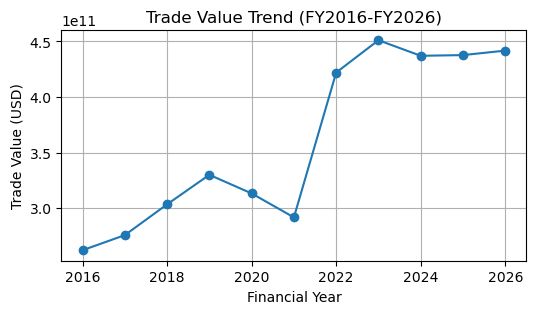

In [59]:

trend_df = pd.read_sql(f'''
SELECT Financial_Year AS Year,
ROUND(SUM(Trade_Value_USD),2) AS Trade_Value
FROM {TABLE_NAME}
GROUP BY Financial_Year
ORDER BY Financial_Year
''', conn)

plt.figure(figsize=(6,3))
plt.plot(trend_df['Year'], trend_df['Trade_Value'], marker='o')
plt.title('Trade Value Trend (FY2016-FY2026)')
plt.xlabel('Financial Year')
plt.ylabel('Trade Value (USD)')
plt.grid(True)
plt.savefig('trade_value_trend.png')
plt.show()


C:\Users\kartv\AppData\Local\Temp\ipykernel_10800\3336607786.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  commodity_df = pd.read_sql(f'''


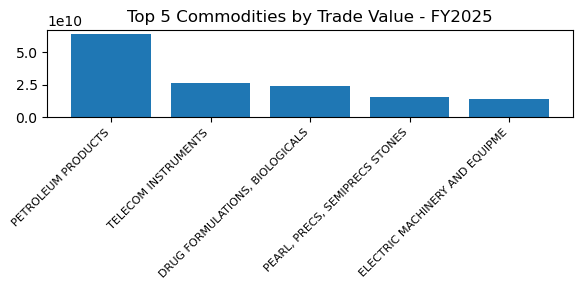

In [60]:

commodity_df = pd.read_sql(f'''
SELECT Commodity,
ROUND(SUM(Trade_Value_USD),2) AS Trade_Value
FROM {TABLE_NAME}
WHERE Financial_Year=%s
GROUP BY Commodity
ORDER BY Trade_Value DESC
LIMIT 5
''', conn, params=(financial_year,))

plt.figure(figsize=(6,3))
plt.bar(commodity_df['Commodity'], commodity_df['Trade_Value'])
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.title(f'Top 5 Commodities by Trade Value - FY{financial_year}')
plt.tight_layout()
plt.savefig('top_commodities.png')
plt.show()


C:\Users\kartv\AppData\Local\Temp\ipykernel_10800\885927112.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  country_df = pd.read_sql(f'''


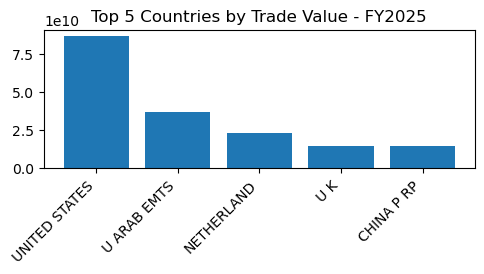

In [61]:

country_df = pd.read_sql(f'''
SELECT Country,
ROUND(SUM(Trade_Value_USD),2) AS Trade_Value
FROM {TABLE_NAME}
WHERE Financial_Year=%s
GROUP BY Country
ORDER BY Trade_Value DESC
LIMIT 5
''', conn, params=(financial_year,))

plt.figure(figsize=(5,3))
plt.bar(country_df['Country'], country_df['Trade_Value'])
plt.xticks(rotation=45, ha='right')
plt.title(f'Top 5 Countries by Trade Value - FY{financial_year}')
plt.tight_layout()
plt.savefig('top_countries.png')
plt.show()


In [ ]:

wb = Workbook()
ws = wb.active
ws.title = 'Export Report'

fill = PatternFill(start_color='4472C4', end_color='4472C4', fill_type='solid')

ws['A1'] = f'Export Performance Report - FY{financial_year}'
ws['A1'].font = Font(size=13, bold=True, color='FFFFFF')
ws['A1'].fill = fill

kpis = [
['Total Trade Value (Billion USD)', total_trade_value],
# ['Total Quantity', total_quantity],
['Countries Traded With', total_countries],
['Commodities Exported', total_commodities],
['Top Commodity', top_commodity],
['Top Country', top_country],
['Top Continent', top_continent],
['Previous FY Trade Value (Billion USD)', previous_trade_value],
['YoY Change (%)', f'{yoy_change}%']
]

row = 3
for k,v in kpis:
    ws.cell(row=row,column=1,value=k)
    ws.cell(row=row,column=2,value=v)
    row += 1

img1 = Image('trade_value_trend.png')
# img1.height = 10
ws.add_image(img1,'D1')

img2 = Image('top_commodities.png')
ws.add_image(img2,'D18')

img3 = Image('top_countries.png')
ws.add_image(img3,'A14')

for sheet in wb.worksheets:
    for col in sheet.columns:
        length = max(len(str(c.value)) if c.value is not None else 0 for c in col)
        sheet.column_dimensions[get_column_letter(col[0].column)].width = length + 5

file_name = f'Export_Report_FY{financial_year}.xlsx'
wb.save(file_name)

print('Report Generated:', file_name)


Report Generated: Export_Report_FY2025.xlsx
